In [193]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [194]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000029B43FCE550> [0]

In [195]:
REGION = 'Nord'
YEAR = 2023

In [196]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [197]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [198]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0


In [199]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (1445035, 24)


Text(0.5, 1.0, 'Year: 2023')

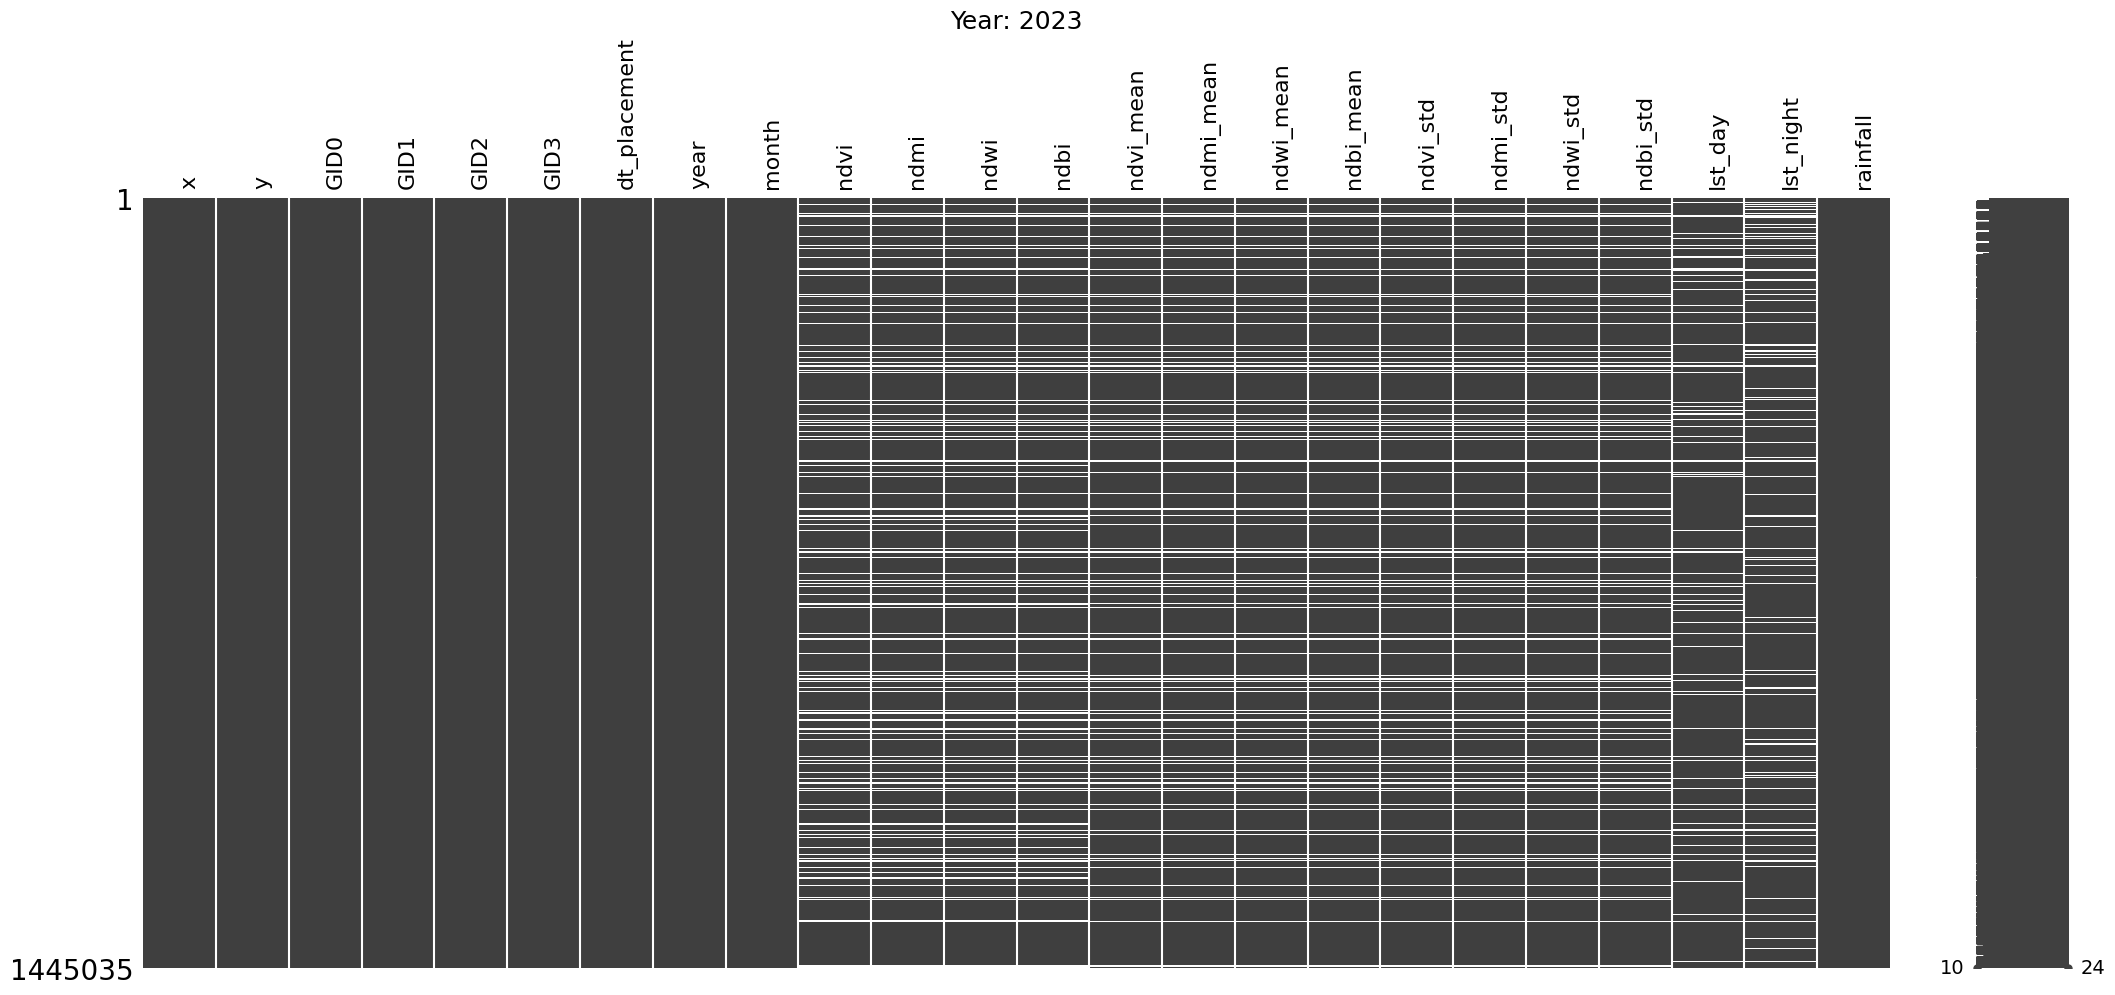

In [200]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [201]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [202]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [203]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0,NaN,0.5,0.866
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0,NaN,0.5,0.866
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0,14899.5,0.5,0.866
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0,14889.0,0.5,0.866
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0,14904.5,0.5,0.866


In [204]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.56021,9.29772,15102.128622,680.892978,2,151.604907,185.418439,180.092206,0.0,1.000000
1,13.59642,9.22586,6838.003488,1865.794331,1,201.794101,197.674022,183.049512,0.0,2.249840
2,13.59642,9.26179,9504.069954,2074.586084,1,136.247919,186.061883,180.318899,0.0,9.050964
3,13.59642,9.29772,12864.041385,781.399397,1,143.777456,188.894941,180.250312,0.0,2.000000
4,13.63262,9.18992,1899.383898,1344.931378,1,151.874866,187.347864,179.798661,0.0,1.000000


In [205]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0,14899.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0,14889.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0,14904.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735


Text(0.5, 1.0, 'Year: 2023')

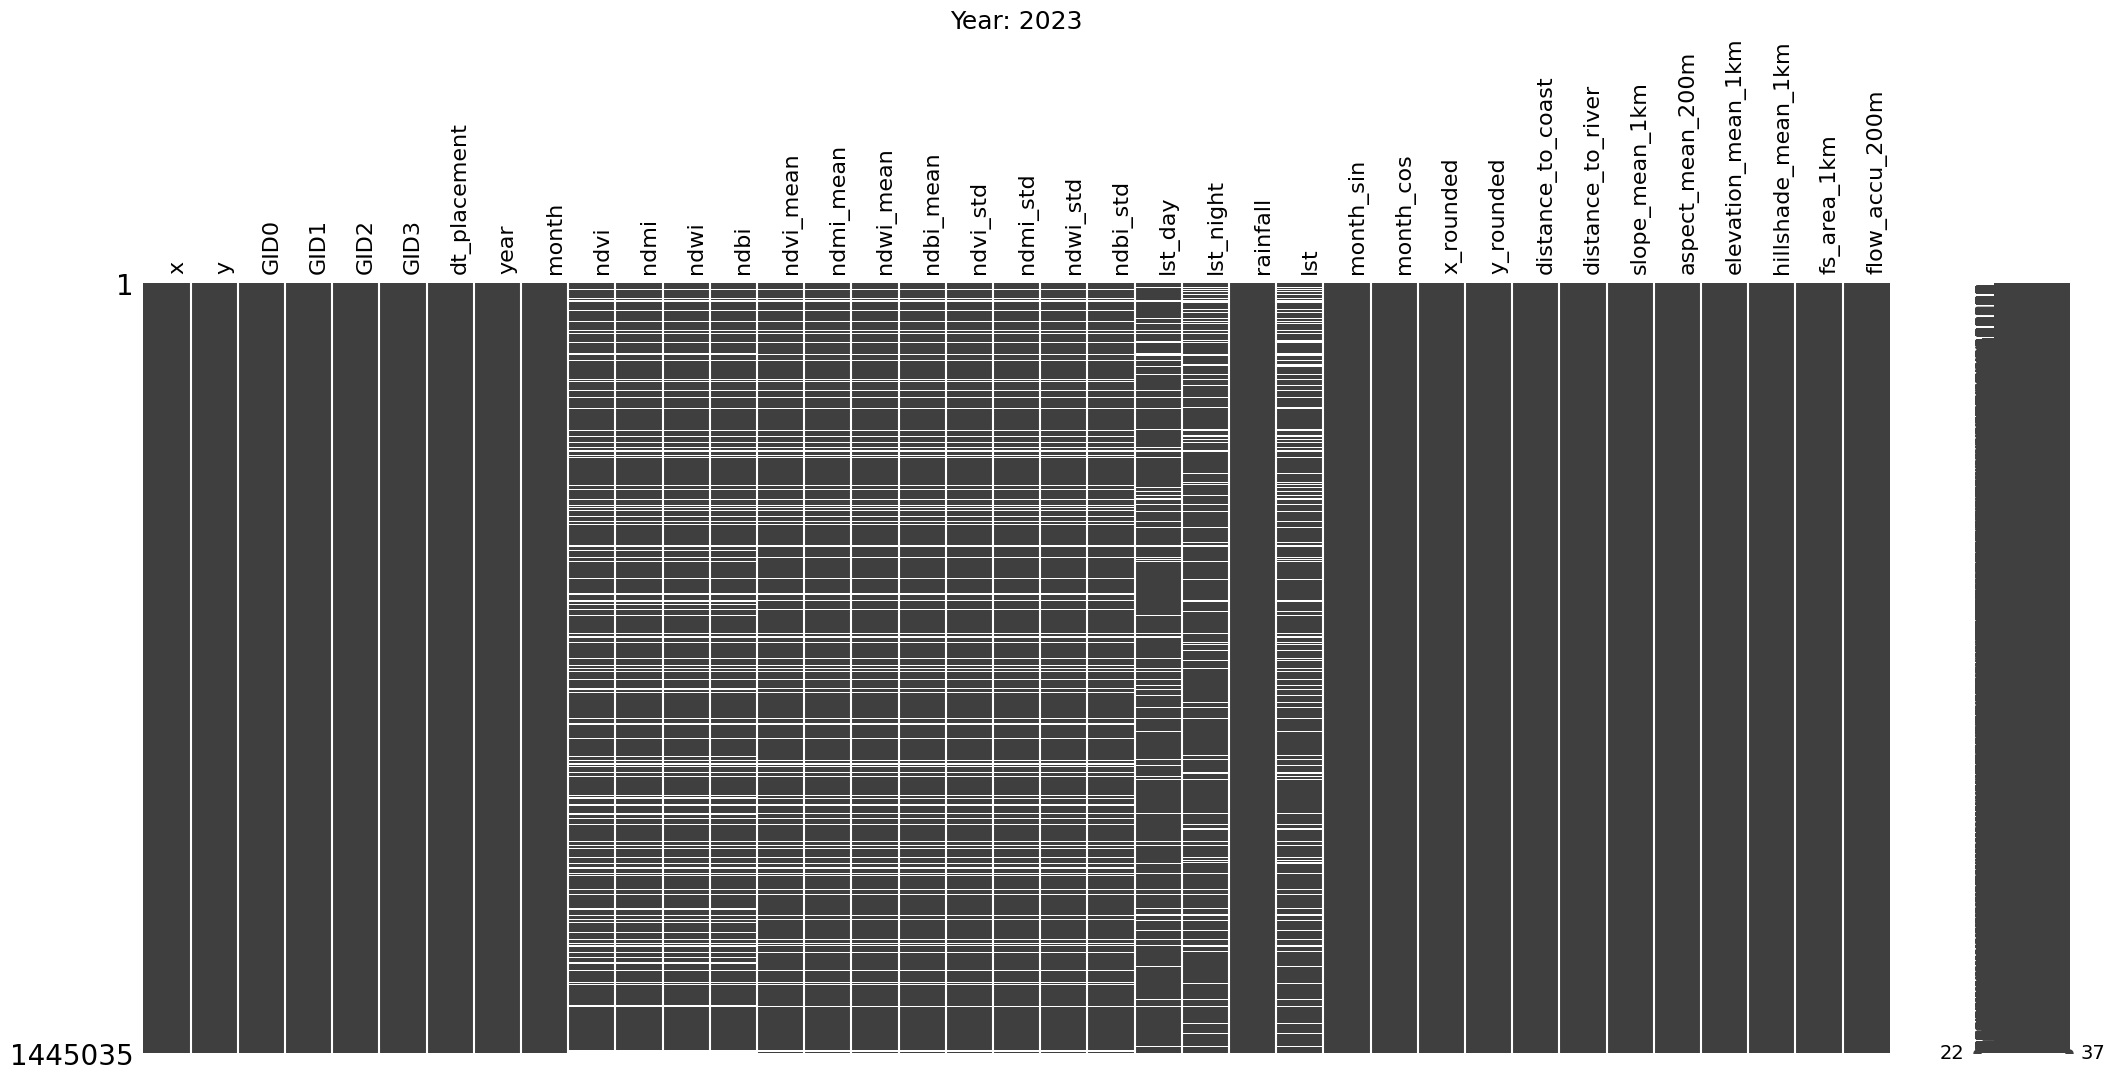

In [206]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [207]:
landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
87098,13.56021,9.29772,2023,31,99,36,98.0,30,99,12,12,1,6,7,2,0
87099,13.59642,9.22586,2023,31,99,36,99.0,30,99,12,12,3,5,8,2,0
87100,13.59642,9.26179,2023,31,98,36,97.0,30,98,12,12,1,6,7,2,0
87101,13.59642,9.29772,2023,31,98,36,97.0,30,98,12,12,1,6,7,2,0
87102,13.63262,9.18992,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [208]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)

landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,96.0,30,99,12,12,1,6,7,2,0
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0,NaN,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,96.0,30,99,12,12,1,6,7,2,0
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0,14899.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,96.0,30,99,12,12,1,6,7,2,0
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0,14889.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,96.0,30,99,12,12,1,6,7,2,0
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0,14904.5,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31,99,36,96.0,30,99,12,12,1,6,7,2,0


In [209]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 90, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 90, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 90, 'lc_prop3'] = np.nan

In [210]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2023')

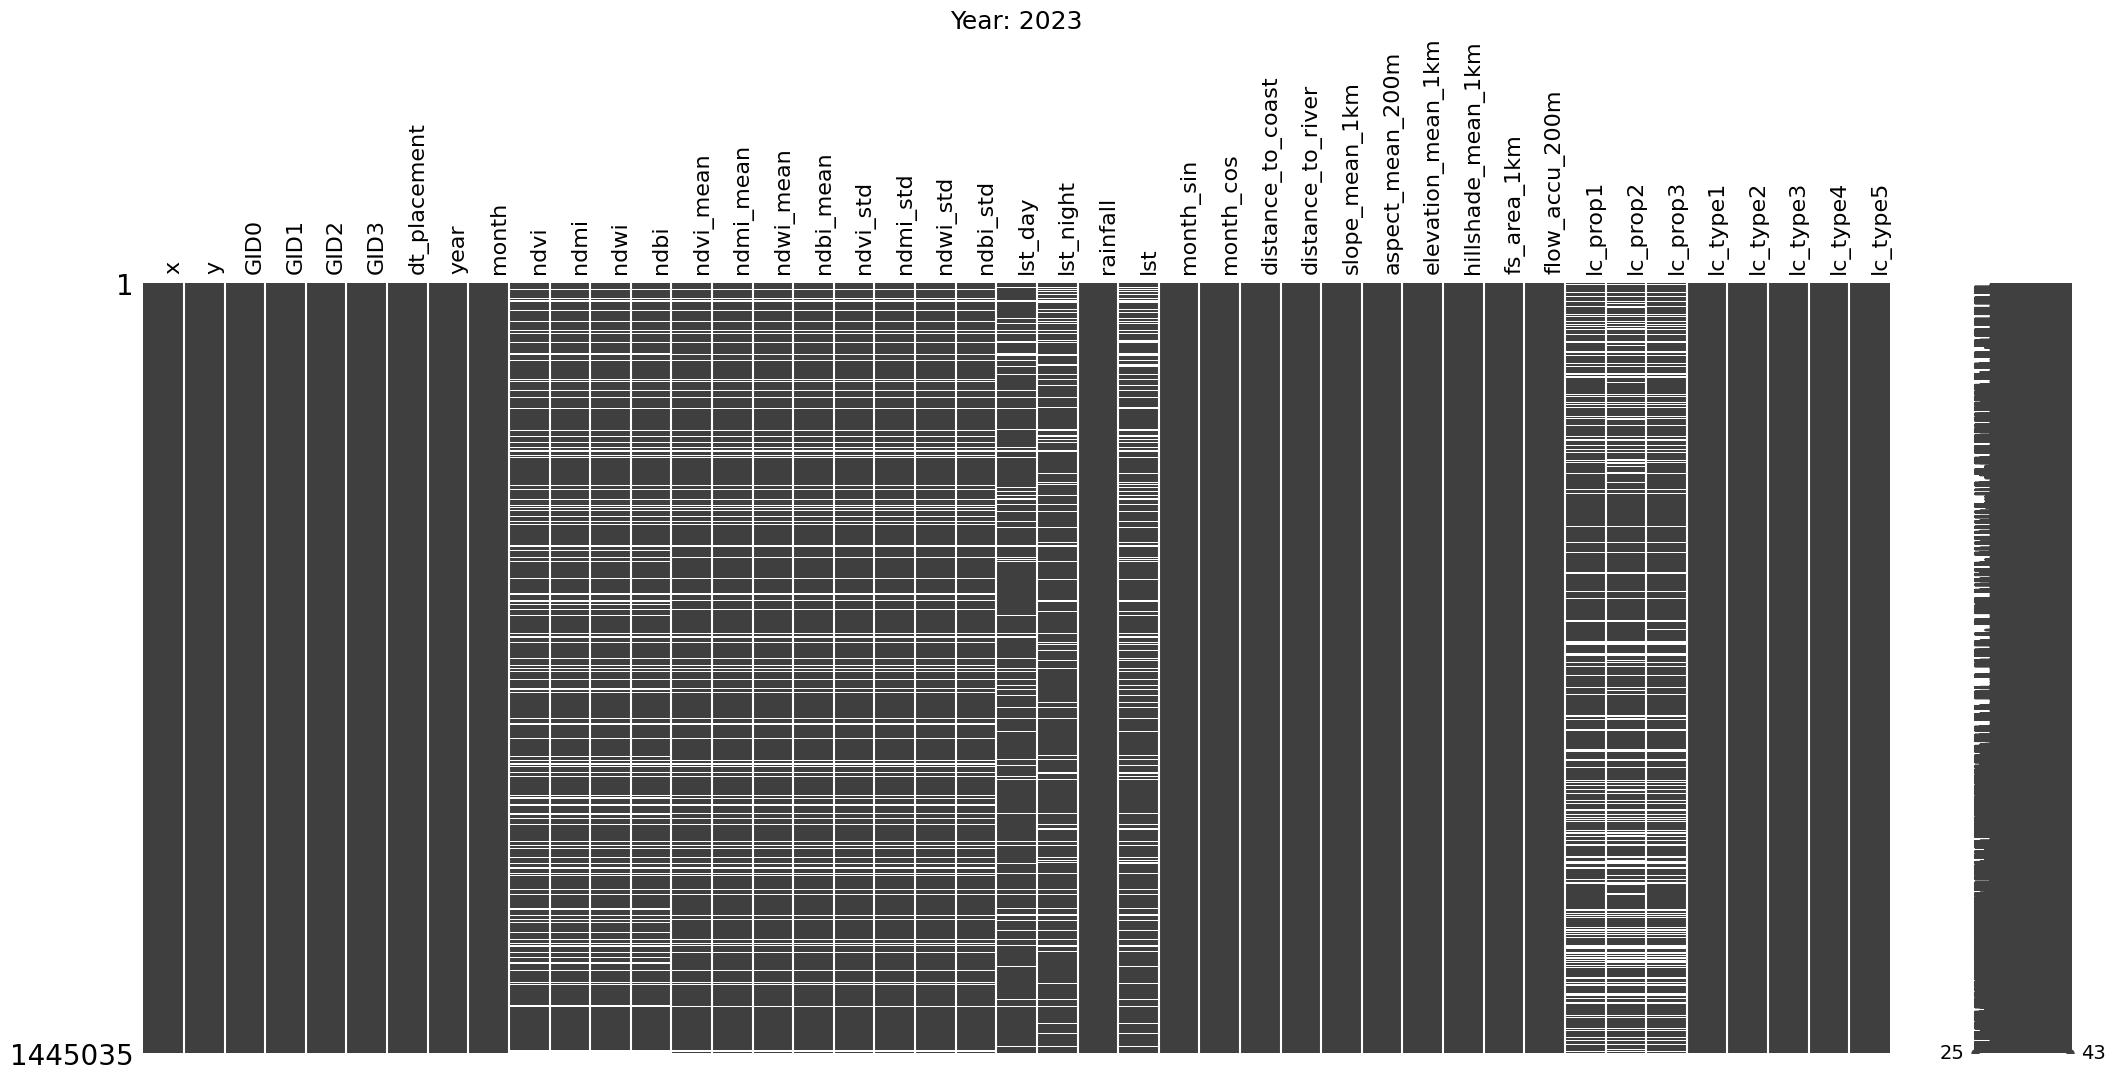

In [211]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [212]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0,NaN,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0,NaN,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0,14899.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0,14889.0,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0,14904.5,0.5,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,31.0,36.0,30.0,12,12,1,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445030,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-27,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,14885.0,14489.0,0.0,14687.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4
1445031,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-28,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15184.0,14489.0,0.0,14836.5,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4
1445032,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-29,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15093.0,14489.0,0.0,14791.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4
1445033,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-30,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15243.0,14403.0,0.0,14823.0,-0.0,1.000,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,22.0,20.0,20.0,9,9,4,4,4


In [213]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [214]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [215]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [216]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [217]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [218]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (52925, 51)


Text(0.5, 1.0, 'Year: 2023.0')

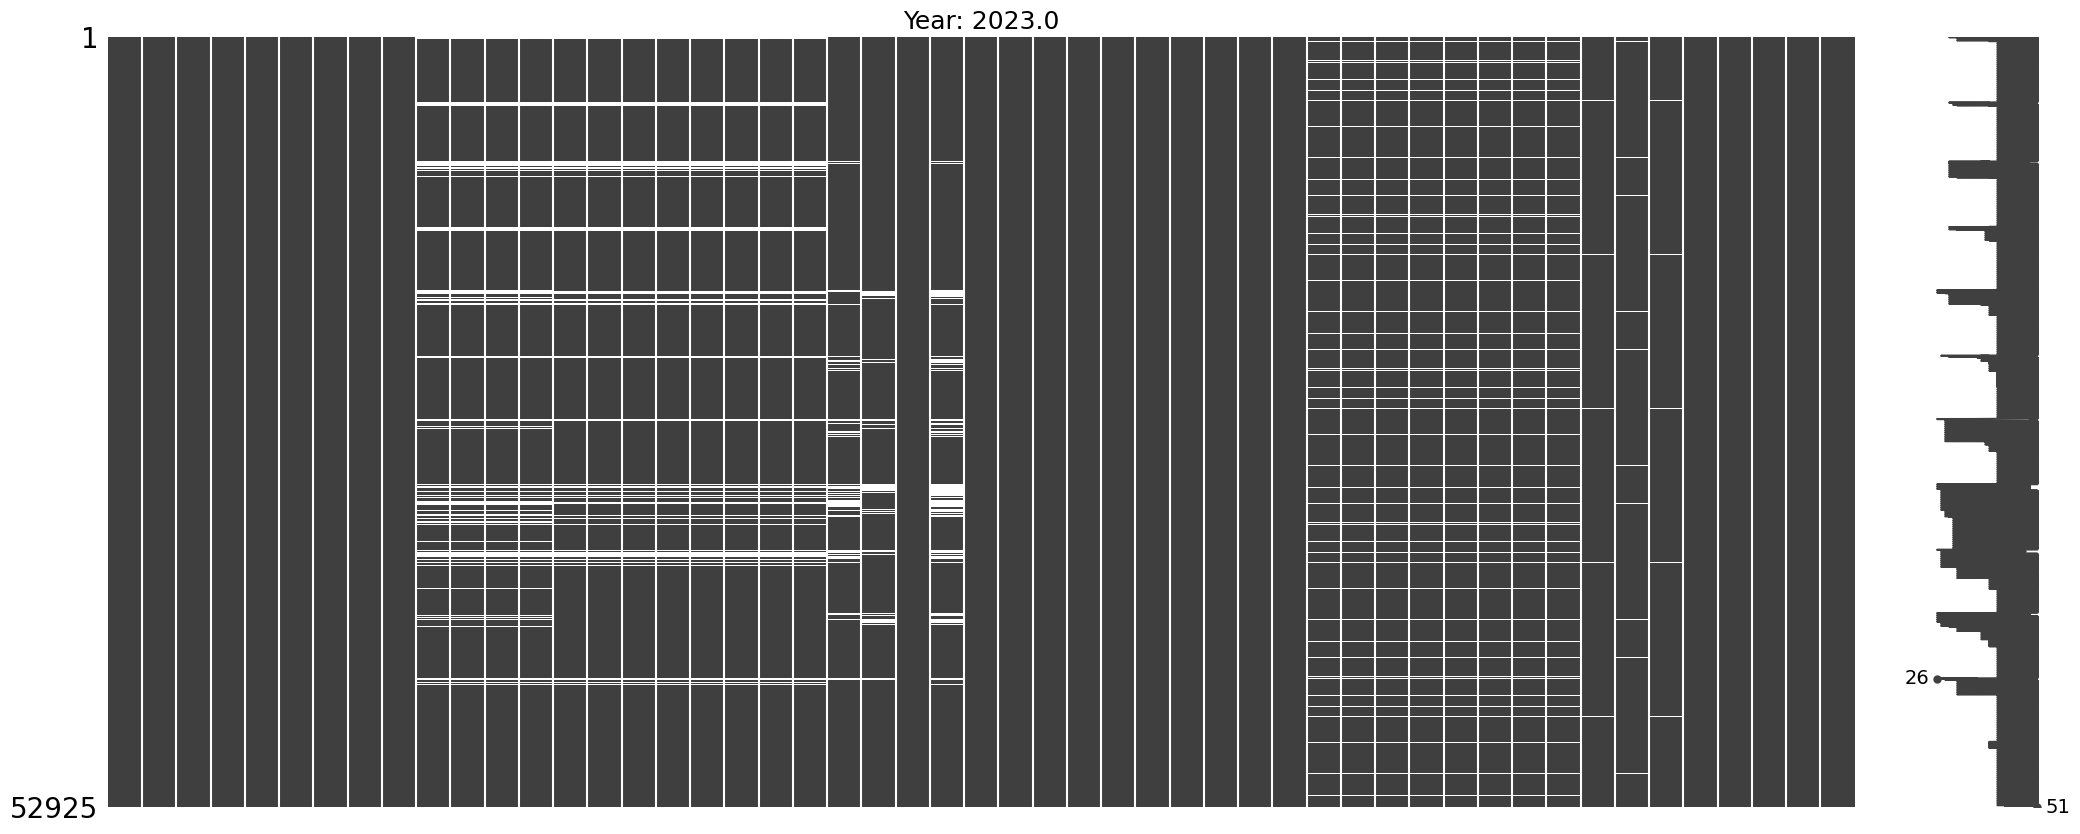

In [219]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=18)

In [220]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [221]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [222]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [223]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2023-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.070000,18.498000,0.000000,24.784000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2023-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.534615,19.738205,0.001538,25.136410,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2023-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.210000,20.168667,0.000000,25.189333,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2023-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997273,17.537273,0.000000,23.767273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8
4,2023-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.576667,19.543333,0.000000,25.060000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


In [224]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [225]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2023-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.070000,18.498000,0.000000,24.784000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2023-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.534615,19.738205,0.001538,25.136410,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2023-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.210000,20.168667,0.000000,25.189333,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2023-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997273,17.537273,0.000000,23.767273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8
4,2023-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.576667,19.543333,0.000000,25.060000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


Text(0.5, 1.0, 'Year: 2023')

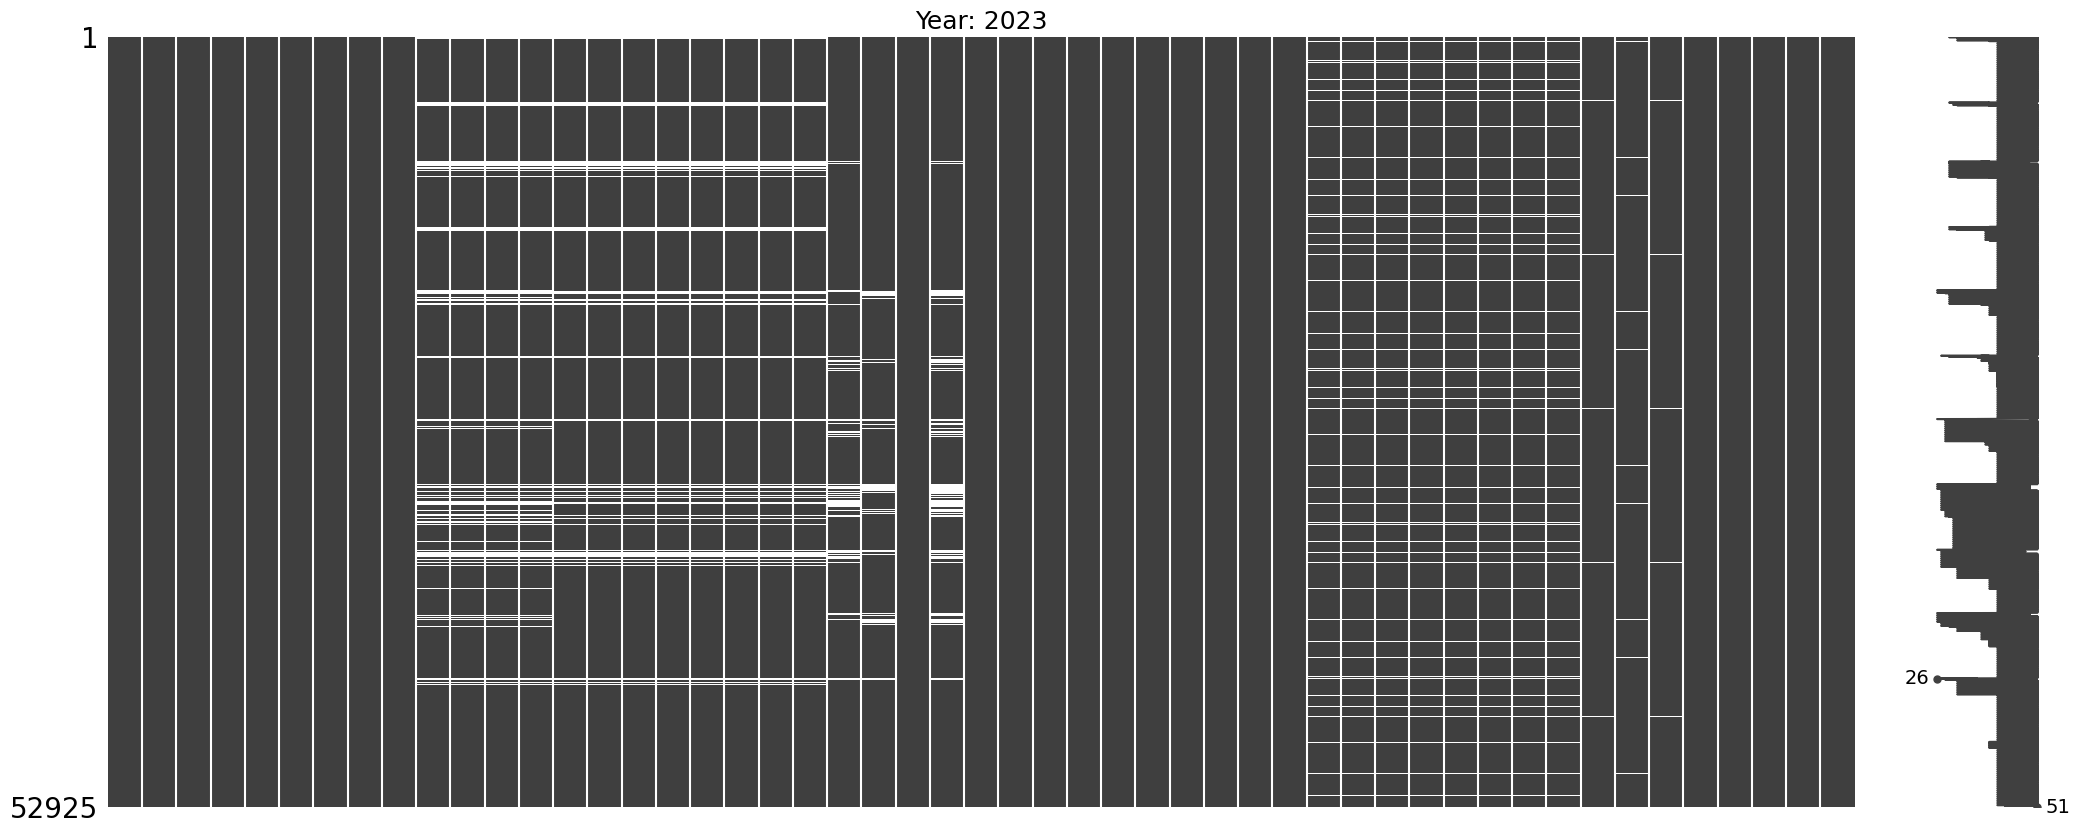

In [226]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=18)

In [227]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [228]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bibemi,adoumri,2023,1,15.326000,43.850000,0.272000
1,bibemi,adoumri,2023,2,16.890000,45.782000,0.554000
2,bibemi,adoumri,2023,3,18.942000,48.142000,28.845799
3,bibemi,adoumri,2023,4,17.738000,49.162000,89.762798
4,bibemi,adoumri,2023,5,23.186000,52.690000,189.023196
...,...,...,...,...,...,...,...
1735,touboro,yanli,2023,8,21.280000,31.276667,624.154954
1736,touboro,yanli,2023,9,19.515161,29.444194,593.719343
1737,touboro,yanli,2023,10,20.336667,33.939032,160.147738
1738,touboro,yanli,2023,11,19.377742,35.742903,89.248707


In [229]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [230]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2023-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.070000,18.498000,0.000000,24.784000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.326000,43.850000,0.272000
1,2023-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.534615,19.738205,0.001538,25.136410,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,15.814103,43.146410,0.222564
2,2023-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.210000,20.168667,0.000000,25.189333,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,16.443333,42.646000,0.201333
3,2023-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997273,17.537273,0.000000,23.767273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8,15.642727,41.988182,0.611818
4,2023-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.576667,19.543333,0.000000,25.060000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,17.910000,42.083333,0.230000


Text(0.5, 1.0, 'Year: 2023')

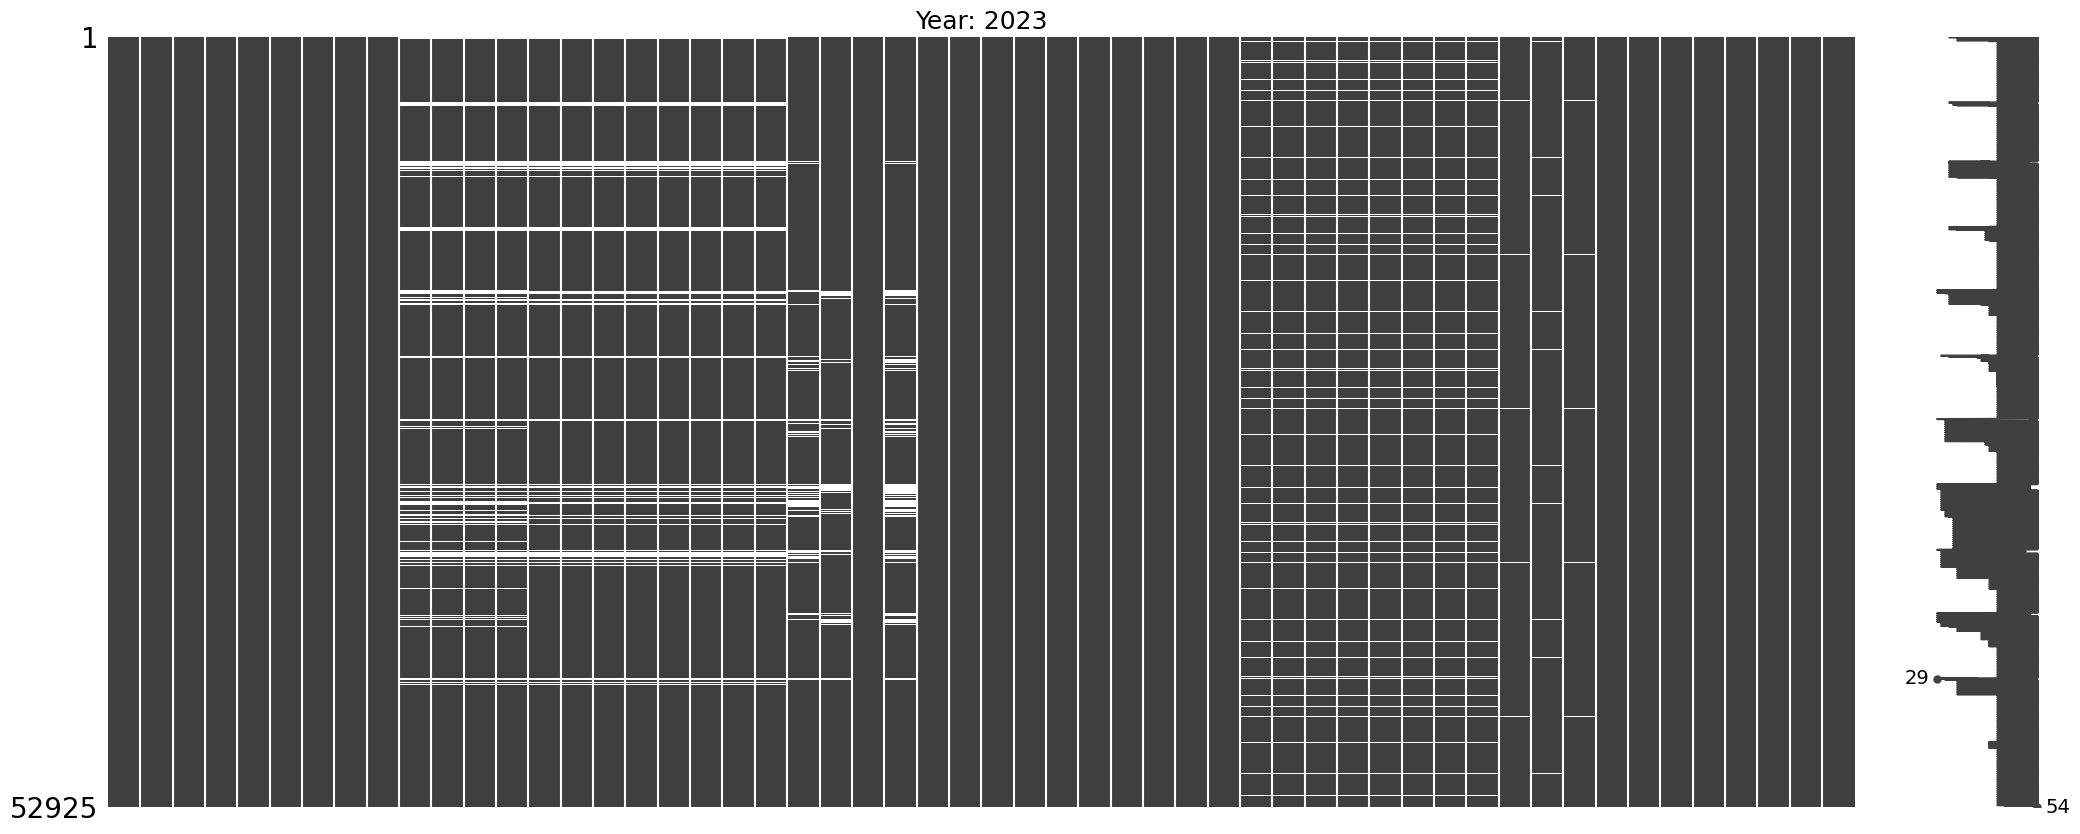

In [231]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [232]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [233]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2023-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.070000,18.498000,0.000000,24.784000,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.326000,43.850000,0.272000,2023-01
1,2023-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.534615,19.738205,0.001538,25.136410,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,15.814103,43.146410,0.222564,2023-01
2,2023-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.210000,20.168667,0.000000,25.189333,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,16.443333,42.646000,0.201333,2023-01
3,2023-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997273,17.537273,0.000000,23.767273,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8,15.642727,41.988182,0.611818,2023-01
4,2023-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.576667,19.543333,0.000000,25.060000,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,17.910000,42.083333,0.230000,2023-01


In [234]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [235]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [236]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2023-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023.0,1.0,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,36.319032,18.292194,0.008774,27.305613,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.326000,43.850000,0.272000
1,2023-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023.0,1.0,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,35.318817,19.266394,0.007179,27.292605,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.814103,43.146410,0.222564
2,2023-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023.0,1.0,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,34.497570,19.383935,0.006495,26.940753,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.443333,42.646000,0.201333
3,2023-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023.0,1.0,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,35.170411,17.750880,0.019736,26.460645,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.642727,41.988182,0.611818
4,2023-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023.0,1.0,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,34.462473,20.399892,0.007419,27.431183,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.910000,42.083333,0.230000


In [237]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (1740, 54)


Text(0.5, 1.0, 'Year: 2023.0')

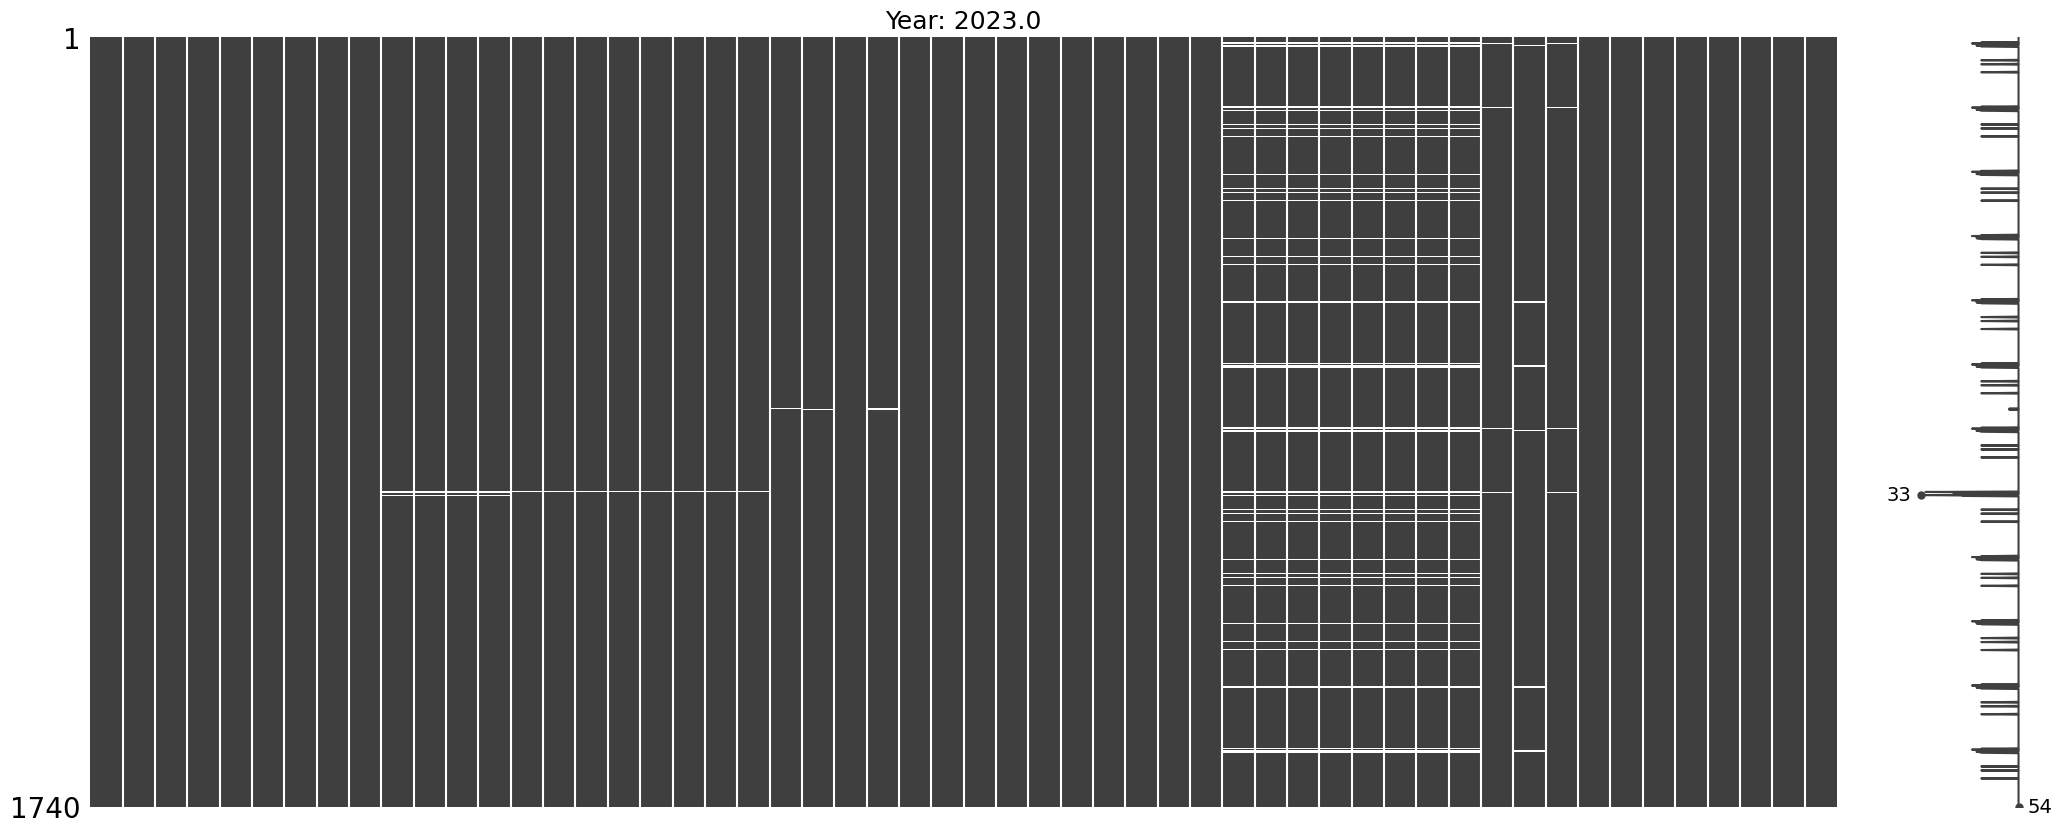

In [238]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [239]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [240]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [241]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [242]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2023-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023,1,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,36.319032,18.292194,0.008774,27.305613,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.326000,43.850000,0.272000
1,2023-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023,1,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,35.318817,19.266394,0.007179,27.292605,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.814103,43.146410,0.222564
2,2023-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023,1,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,34.497570,19.383935,0.006495,26.940753,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.443333,42.646000,0.201333
3,2023-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023,1,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,35.170411,17.750880,0.019736,26.460645,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.642727,41.988182,0.611818
4,2023-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023,1,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,34.462473,20.399892,0.007419,27.431183,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.910000,42.083333,0.230000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2023-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2023,12,0.405491,0.015092,-0.335983,-0.015092,0.404507,0.018448,-0.335468,-0.018448,0.021516,0.026020,0.016624,0.026020,27.679898,17.458801,0.027375,22.569350,0.0,1.000,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,14.543504,30.579573,0.848632
1736,2023-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2023,12,0.364786,-0.031907,-0.352342,0.031907,0.360214,-0.029610,-0.345435,0.029610,0.024162,0.028642,0.016078,0.028642,29.914038,18.520844,0.014388,24.217441,0.0,1.000,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,31.0,36.0,30.0,9.0,9.0,4.0,4.0,4.0,15.460690,33.291724,0.446034
1737,2023-12,nord,mayo-rey,toub

In [243]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [244]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2023-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023,1,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,36.319032,18.292194,0.008774,27.305613,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.326000,43.850000,0.272000,0.272000
1,2023-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023,1,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,35.318817,19.266394,0.007179,27.292605,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.814103,43.146410,0.222564,0.222564
2,2023-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023,1,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,34.497570,19.383935,0.006495,26.940753,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.443333,42.646000,0.201333,0.201333
3,2023-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023,1,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,35.170411,17.750880,0.019736,26.460645,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.642727,41.988182,0.611818,0.611818
4,2023-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023,1,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,34.462473,20.399892,0.007419,27.431183,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.910000,42.083333,0.230000,0.230000


In [245]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [246]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [247]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2023,1,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,36.319032,18.292194,0.008774,27.305613,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.326000,43.850000,0.272000,0.272000,29.583333,20.666667,55.855856,349.566832,52.0,15.0,37.0,26.166667,29.333333,34.500000,26.166667,2048.0,510.0,0.0,107.959705,1270.0,4.0,306.0,1270.0
1,2023-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2023,1,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,35.318817,19.266394,0.007179,27.292605,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.814103,43.146410,0.222564,0.222564,29.166667,18.833333,53.809524,326.366591,50.0,15.0,35.0,25.833333,29.000000,33.666667,25.666667,1975.0,470.0,0.0,104.359708,1188.0,1.0,315.0,1028.0
2,2023-01,nord,benoue,bibemi,bide,13.972945,9.422292,2023,1,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,34.497570,19.383935,0.006495,26.940753,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.443333,42.646000,0.201333,0.201333,29.500000,19.333333,55.238095,311.885760,51.0,16.0,35.0,27.000000,28.666667,34.000000,26.333333,1843.0,450.0,0.0,106.749578,1165.0,0.0,285.0,960.0
3,2023-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2023,1,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,35.170411,17.750880,0.019736,26.460645,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.642727,41.988182,0.611818,0.611818,29.333333,18.833333,57.070707,296.443566,48.0,15.0,33.0,26.833333,27.833333,33.833333,26.833333,2093.0,475.0,0.0,104.824494,1267.0,1.0,325.0,1267.0
4,2023-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2023,1,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,34.462473,20.399892,0.007419,27.431183,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,17.910000,42.083333,0.230000,0.230000,29.875000,19.083333,59.635417,263.822427,49.0,17.0,32.0,27.500000,29.166667,33.833333,27.166667,1826.0,447.0,0.0,110.292126,1191.0,0.0,254.0,963.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

Text(0.5, 1.0, 'Year: 2023')

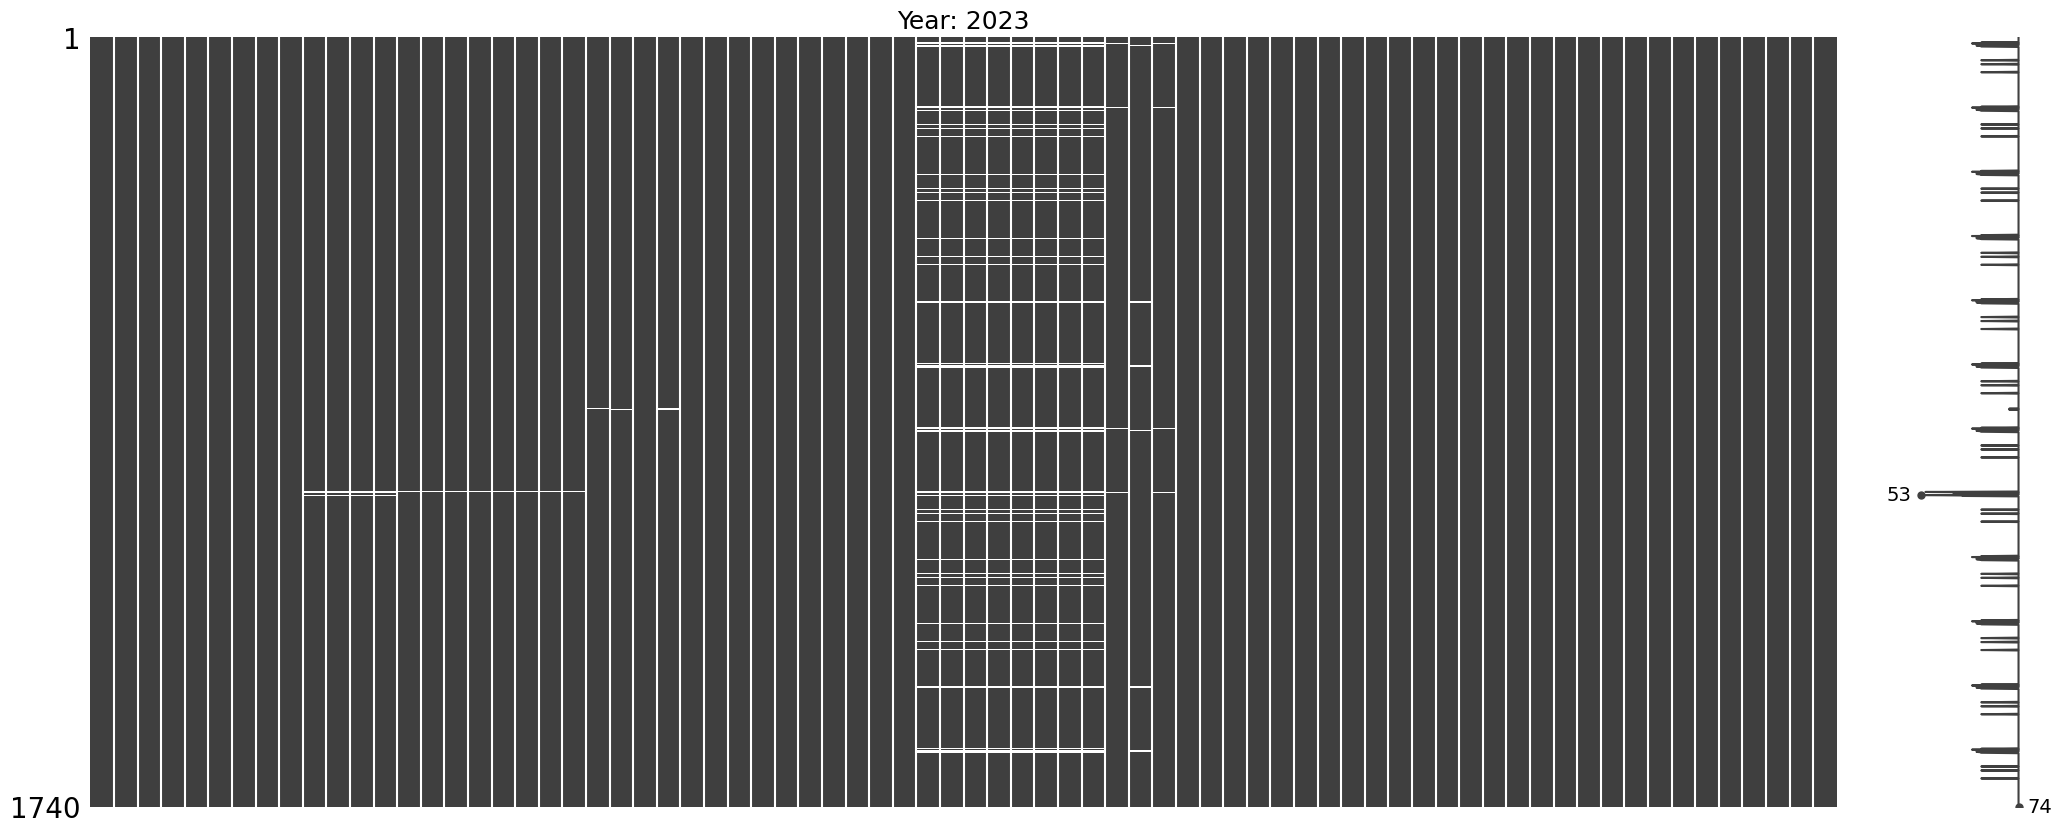

In [248]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [249]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [250]:
dataset.shape

(1740, 74)

In [251]:
new_order = ['dt_placement',
             'year',
             'month',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [252]:
dataset = dataset[new_order]

In [253]:
dataset.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,27.31,36.32,18.29,15.33,43.85,0.0088,0.2720,0.2720,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,27.29,35.32,19.27,15.81,43.15,0.0072,0.2226,0.2226,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,26.94,34.50,19.38,16.44,42.65,0.0065,0.2013,0.2013,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,26.46,35.17,17.75,15.64,41.99,0.0197,0.6118,0.6118,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,3,5,8,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,2023-01,2023,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,27.43,34.46,20.40,17.91,42.08,0.0074,0.2300,0.2300,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [254]:
dataset.shape

(1740, 74)

In [255]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 74 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1740 non-null   period[M]
 1   year                    1740 non-null   int32    
 2   month                   1740 non-null   int32    
 3   month_sin               1740 non-null   float64  
 4   month_cos               1740 non-null   float64  
 5   GID0                    1740 non-null   object   
 6   GID1                    1740 non-null   object   
 7   GID2                    1740 non-null   object   
 8   GID3                    1740 non-null   object   
 9   x                       1740 non-null   float64  
 10  y                       1740 non-null   float64  
 11  ndvi                    1735 non-null   float64  
 12  ndmi                    1735 non-null   float64  
 13  ndwi                    1735 non-null   float64  
 14  ndbi    

In [256]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)